# DBSCAN Cosine

**PERSIAPAN**

1. import library

In [ ]:
# Import Library
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

from google.colab import drive
drive.mount('/content/drive')

# Set Library
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputKmeans"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Library berhasil diinstall.
[INFO] Folder output: 'outputKmeans' | Random state: 42


In [ ]:

print(os.listdir('/content/drive/MyDrive/glucosafe'))

path = '/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip'
df = pd.read_csv(path)
print(df.shape)
df.head()

['Datasate']
(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip'
df_raw = pd.read_csv(path)
print(df_raw.shape)
df_raw.head()

(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df_raw['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 23899

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [ ]:
# Preprocessing
df = df_raw.copy()
n_awal = len(df)

# Buang kelas 1 (pra-diabetes), fokus ke diabetes vs tidak
df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")  # laporan jumlah baris setelah kelas 1 dibuang

# Membuang kolom income
df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Menghapus baris duplikat
n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

# Rapikan nomor baris jadi 0,1,2,... lagi
df = df.reset_index(drop=True)

# Pisahkan tabel fitur dan label
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Bentuk data siap klaster: {X_scaled.shape}")
print(f"Cek mean 0 dan std 1: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
df_features.head()

Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster: (208858, 20)
Cek mean 0 dan std 1: -0.0000 / 1.0000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0


**DBSCAN Cosine**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import time

X = df.values   # data hasil standarisasi
min_samples_awal = 16   # 2 x jumlah fitur (8 fitur)

K-distance plot

[INFO] Ukuran data penuh: (208858, 21) | Ukuran sampel: (15000, 21)


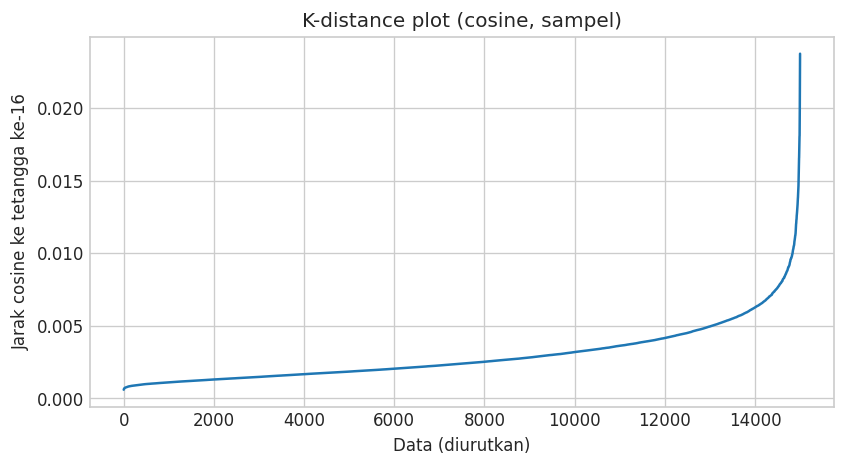

Persentil 50/70/80/90/95: [0.0024 0.0034 0.0042 0.0055 0.0068]


In [ ]:
# K-distance plot (cosine) - memakai sampel agar tidak terlalu berat
from sklearn.neighbors import NearestNeighbors

N_SAMPLE = 15000
X_arr = np.asarray(X)                      # aman untuk DataFrame maupun array
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(X_arr.shape[0], min(N_SAMPLE, X_arr.shape[0]), replace=False)
X_sample = X_arr[idx]
print(f"[INFO] Ukuran data penuh: {X_arr.shape} | Ukuran sampel: {X_sample.shape}")

nn = NearestNeighbors(n_neighbors=min_samples_awal, metric='cosine', n_jobs=-1).fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
k_dist = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.xlabel('Data (diurutkan)')
plt.ylabel(f'Jarak cosine ke tetangga ke-{min_samples_awal}')
plt.title('K-distance plot (cosine, sampel)')
plt.show()

print('Persentil 50/70/80/90/95:', np.percentile(k_dist, [50, 70, 80, 90, 95]).round(4))

**Eksperimen eps dan min_samples**

In [ ]:
# Eksperimen eps dan min_samples (DBSCAN cosine, memakai sampel)
persentil_list = [50, 70, 80, 90, 95]
ms_list = [8, 16, 32]

baris = []
for p in persentil_list:
    eps = float(np.percentile(k_dist, p))
    for ms in ms_list:
        mulai = time.time()
        lab = DBSCAN(eps=eps, min_samples=ms, metric='cosine', n_jobs=-1).fit_predict(X_sample)
        mask = lab != -1
        n_cl = len(set(lab[mask]))
        if n_cl >= 2:
            sil = silhouette_score(X_sample[mask], lab[mask], metric='cosine',
                                   sample_size=min(3000, int(mask.sum())), random_state=RANDOM_STATE)
        else:
            sil = np.nan
        baris.append({'eps': round(eps, 4), 'min_samples': ms, 'Klaster': n_cl,
                      'Noise': int((~mask).sum()), 'Noise (%)': round(100 * (~mask).mean(), 1),
                      'Silhouette': round(sil, 3)})
        print(f"[INFO] persentil={p}, eps={eps:.4f}, min_samples={ms} selesai ({time.time() - mulai:.1f} detik)")

grid_cosine = pd.DataFrame(baris)
grid_cosine

[INFO] persentil=50, eps=0.0024, min_samples=8 selesai (21.0 detik)
[INFO] persentil=50, eps=0.0024, min_samples=16 selesai (6.5 detik)
[INFO] persentil=50, eps=0.0024, min_samples=32 selesai (6.1 detik)
[INFO] persentil=70, eps=0.0034, min_samples=8 selesai (6.6 detik)
[INFO] persentil=70, eps=0.0034, min_samples=16 selesai (6.1 detik)
[INFO] persentil=70, eps=0.0034, min_samples=32 selesai (7.3 detik)
[INFO] persentil=80, eps=0.0042, min_samples=8 selesai (5.5 detik)
[INFO] persentil=80, eps=0.0042, min_samples=16 selesai (6.9 detik)
[INFO] persentil=80, eps=0.0042, min_samples=32 selesai (6.3 detik)
[INFO] persentil=90, eps=0.0055, min_samples=8 selesai (5.5 detik)
[INFO] persentil=90, eps=0.0055, min_samples=16 selesai (7.3 detik)
[INFO] persentil=90, eps=0.0055, min_samples=32 selesai (6.0 detik)
[INFO] persentil=95, eps=0.0068, min_samples=8 selesai (7.5 detik)
[INFO] persentil=95, eps=0.0068, min_samples=16 selesai (6.0 detik)
[INFO] persentil=95, eps=0.0068, min_samples=32 sele

,eps,min_samples,Klaster,Noise,Noise (%),Silhouette
0,0.0024,8,18,3695,24.6,0.122
1,0.0024,16,6,4827,32.2,0.528
2,0.0024,32,3,6026,40.2,0.930
3,0.0034,8,9,1555,10.4,-0.075
4,0.0034,16,7,2283,15.2,0.504
5,0.0034,32,6,3496,23.3,0.652
6,0.0042,8,6,762,5.1,-0.079
7,0.0042,16,1,1301,8.7,NaN
8,0.0042,32,3,2116,14.1,0.725
9,0.0055,8,1,225,1.5,NaN


**Pilih parameter dan model final**

In [ ]:
# Pilih otomatis: klaster >= 2, noise <= 30%, Silhouette tertinggi
kandidat = grid_cosine[(grid_cosine['Klaster'] >= 2) & (grid_cosine['Noise (%)'] <= 30)]
if len(kandidat) > 0:
    pilih = kandidat.sort_values('Silhouette', ascending=False).iloc[0]
    eps_final, ms_final = float(pilih['eps']), int(pilih['min_samples'])
else:
    eps_final, ms_final = float(np.percentile(k_dist, 90)), 16

# Atur manual bila perlu, contoh:
# eps_final, ms_final = 0.12, 16

start_time_dbscan = time.time()
db_cos = DBSCAN(eps=eps_final, min_samples=ms_final, metric='cosine', n_jobs=-1)
y_dbscan = db_cos.fit_predict(X_sample)
end_time_dbscan = time.time()

n_clusters_ = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise_ = list(y_dbscan).count(-1)

print(f'[INFO] Data yang dipakai: sampel {X_sample.shape[0]} baris')
print(f'eps = {eps_final}, min_samples = {ms_final}')
print('Jumlah klaster:', n_clusters_)
print('Jumlah noise  :', n_noise_)
print('Anggota per label (-1 = noise):', dict(zip(*np.unique(y_dbscan, return_counts=True))))
print(f'Waktu komputasi: {end_time_dbscan - start_time_dbscan:.1f} detik')

[INFO] Data yang dipakai: sampel 15000 baris
eps = 0.0042, min_samples = 32
Jumlah klaster: 3
Jumlah noise  : 2075
Anggota per label (-1 = noise): {np.int64(-1): np.int64(2075), np.int64(0): np.int64(12248), np.int64(1): np.int64(377), np.int64(2): np.int64(300)}
Waktu komputasi: 16.5 detik


**Visualisasi**

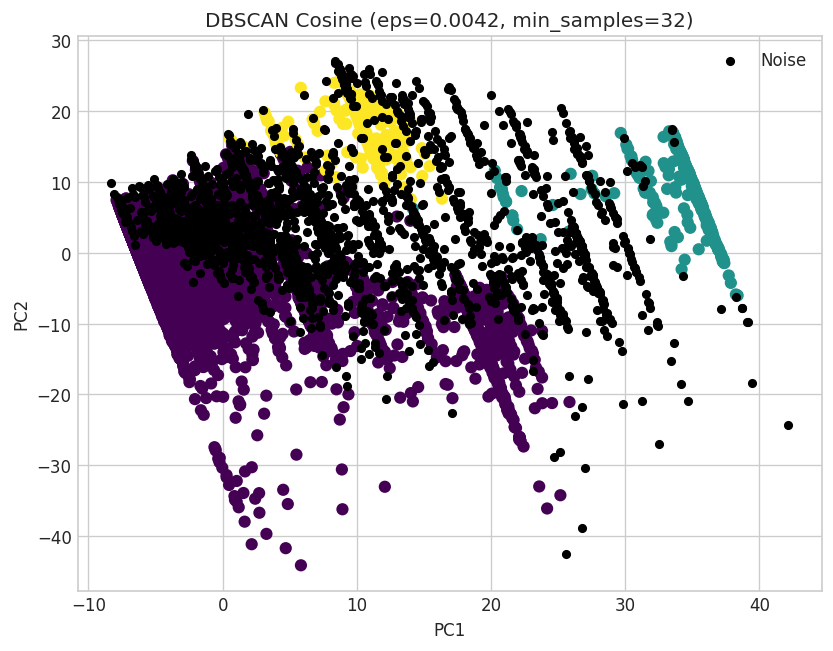

[INFO] Varians dijelaskan PC1+PC2: 71.2%


In [ ]:
from sklearn.decomposition import PCA

# Reduksi ke 2 dimensi untuk visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)
komp = pca.fit_transform(X_sample)

noise = y_dbscan == -1

plt.figure(figsize=(8, 6))
plt.scatter(komp[~noise, 0], komp[~noise, 1],
            c=y_dbscan[~noise], s=40, cmap='viridis')
plt.scatter(komp[noise, 0], komp[noise, 1],
            c='black', s=20, label='Noise')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN Cosine (eps={eps_final}, min_samples={ms_final})')
plt.legend()
plt.show()

print(f'[INFO] Varians dijelaskan PC1+PC2: {pca.explained_variance_ratio_.sum() * 100:.1f}%')

**Evaluasi**

In [ ]:
mask = y_dbscan != -1

if len(set(y_dbscan[mask])) >= 2:
    sil_cos = silhouette_score(X_sample[mask], y_dbscan[mask], metric='cosine')
    sil_euc = silhouette_score(X_sample[mask], y_dbscan[mask])
    dbi = davies_bouldin_score(X_sample[mask], y_dbscan[mask])
    chi = calinski_harabasz_score(X_sample[mask], y_dbscan[mask])
else:
    sil_cos = sil_euc = dbi = chi = np.nan

hasil_dbscan_cosine = pd.DataFrame({
    'Metode': ['DBSCAN Cosine'],
    'Jumlah Data': [X_sample.shape[0]],
    'eps': [eps_final],
    'min_samples': [ms_final],
    'Klaster': [n_clusters_],
    'Noise': [n_noise_],
    'Silhouette (cosine)': [sil_cos],
    'Silhouette (euclidean)': [sil_euc],
    'DBI': [dbi],
    'CHI': [chi],
    'Execution Time': [end_time_dbscan - start_time_dbscan],
})

print("=" * 80)
print("TABEL EVALUASI DBSCAN COSINE (tanpa titik noise)")
print("=" * 80)
print(hasil_dbscan_cosine.to_string(index=False))

TABEL EVALUASI DBSCAN COSINE (tanpa titik noise)
       Metode  Jumlah Data    eps  min_samples  Klaster  Noise  Silhouette (cosine)  Silhouette (euclidean)      DBI         CHI  Execution Time
DBSCAN Cosine        15000 0.0042           32        3   2075             0.729019                 0.56146 0.554775 3102.522945       16.517607
